# Smart Campus Tour & Information Multi-Modal Chatbot

End-to-end Colab notebook for the multimodal campus assistant.

## Environment Setup

Installing the packages used by the project.

In [1]:
!apt-get -qq update
!apt-get -qq install -y ffmpeg espeak-ng
!pip -q install streamlit pandas numpy pillow matplotlib seaborn scikit-learn wordcloud
!pip -q install torch transformers datasets accelerate sentence-transformers faiss-cpu openai-whisper librosa soundfile opencv-python-headless

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libpcaudio0:amd64.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../libpcaudio0_1.1-6build2_amd64.deb ...
Unpacking libpcaudio0:amd64 (1.1-6build2) ...
Selecting previously unselected package libsonic0:amd64.
Preparing to unpack .../libsonic0_0.2.0-11build1_amd64.deb ...
Unpacking libsonic0:amd64 (0.2.0-11build1) ...
Selecting previously unselected package espeak-ng-data:amd64.
Preparing to unpack .../espeak-ng-data_1.50+dfsg-10ubuntu0.1_amd64.deb ...
Unpacking espeak-ng-data:amd64 (1.50+dfsg-10ubuntu0.1) ...
Selecting previously unselected package libespeak-ng1:amd64.
Preparing to unpack .../libespeak-ng1_1.50+dfsg-10ubuntu0.1_amd64.deb ...
Unpacking libespeak-ng1:amd64 (1.50+dfsg-10ubuntu0.1) ...
Selecting previ

## Environment verifing

Recording Python, package, GPU, and FFmpeg details.

In [2]:
import importlib
import platform
import subprocess
import sys
from pathlib import Path

BASE = Path('/content/smart_campus_colab')
DATA_DIR = BASE / 'data'
FIGURES_DIR = BASE / 'reports' / 'figures'
RESULTS_DIR = BASE / 'reports' / 'results'
MODEL_DIR = BASE / 'models'
for path in [DATA_DIR / 'campus_images', DATA_DIR / 'audio_queries', FIGURES_DIR, RESULTS_DIR, MODEL_DIR / 'nlp', MODEL_DIR / 'fusion']:
    path.mkdir(parents=True, exist_ok=True)

packages = ['torch', 'transformers', 'sentence_transformers', 'faiss', 'whisper', 'cv2', 'librosa', 'streamlit', 'pandas', 'numpy', 'sklearn']
lines = [
    f'Python: {sys.version}',
    f'Platform: {platform.platform()}',
]
for package in packages:
    try:
        module = importlib.import_module(package)
        lines.append(f'{package}: {getattr(module, "__version__", "installed")}')
    except Exception as exc:
        lines.append(f'{package}: unavailable ({exc})')
try:
    import torch
    lines.append(f'CUDA available: {torch.cuda.is_available()}')
    lines.append(f'CUDA device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU runtime"}')
except Exception as exc:
    lines.append(f'CUDA check failed: {exc}')
try:
    ffmpeg_version = subprocess.check_output(['ffmpeg', '-version'], text=True).splitlines()[0]
    lines.append(ffmpeg_version)
except Exception as exc:
    lines.append(f'ffmpeg unavailable: {exc}')

proof = '\n'.join(lines)
print(proof)
(RESULTS_DIR / 'environment_proof.txt').write_text(proof, encoding='utf-8')

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
torch: 2.11.0+cu128
transformers: 5.10.2
sentence_transformers: 5.5.1
faiss: 1.14.3
whisper: 20250625
cv2: 4.13.0
librosa: 0.11.0
streamlit: 1.58.0
pandas: 2.2.2
numpy: 2.0.2
sklearn: 1.6.1
CUDA available: True
CUDA device: Tesla T4
ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers


422

## Campus Dataset and Knowledge Base

Creating the campus records, JSON export, and SQLite database.

In [3]:
import json
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd

locations = json.loads(r'''
[
  {
    "id": 1,
    "name": "Library",
    "category": "Learning",
    "description": "A four-floor academic library with silent study rooms, group booths, assistive technology, archives, and a staffed research help desk.",
    "opening_hours": "Mon-Fri 08:00-22:00; Sat-Sun 10:00-18:00",
    "coordinates": {
      "lat": 51.7538,
      "lon": -1.2541
    },
    "events": [
      "Referencing workshop every Tuesday",
      "Exam revision clinic in May",
      "Digital archives showcase"
    ]
  },
  {
    "id": 2,
    "name": "Student Union",
    "category": "Student Services",
    "description": "Central student life building with societies office, advice centre, event hall, student shop, and wellbeing drop-in spaces.",
    "opening_hours": "Mon-Fri 09:00-20:00; Sat 11:00-16:00; Sun closed",
    "coordinates": {
      "lat": 51.7545,
      "lon": -1.2552
    },
    "events": [
      "Freshers fair",
      "Society showcase",
      "International student mixer"
    ]
  },
  {
    "id": 3,
    "name": "Cafeteria",
    "category": "Food",
    "description": "Main campus dining venue serving breakfast, hot lunches, vegetarian meals, halal options, coffee, and grab-and-go snacks.",
    "opening_hours": "Mon-Fri 07:30-19:00; Sat-Sun 09:00-15:00",
    "coordinates": {
      "lat": 51.7541,
      "lon": -1.2531
    },
    "events": [
      "World food week",
      "Student meal deal launch",
      "Sustainability lunch talk"
    ]
  },
  {
    "id": 4,
    "name": "Computer Lab",
    "category": "Learning",
    "description": "Specialist computing lab with GPU workstations, Python environments, VR kits, printing, and technical support for AI modules.",
    "opening_hours": "Mon-Fri 08:00-21:00; Sat 10:00-17:00; Sun closed",
    "coordinates": {
      "lat": 51.755,
      "lon": -1.2526
    },
    "events": [
      "Python bootcamp",
      "Data science clinic",
      "Hackathon preparation session"
    ]
  },
  {
    "id": 5,
    "name": "Lecture Hall A",
    "category": "Teaching",
    "description": "Large tiered lecture theatre with 300 seats, induction loop, dual projection, lecture capture, and accessible front-row seating.",
    "opening_hours": "Mon-Fri 08:00-18:00; weekend by booking",
    "coordinates": {
      "lat": 51.7549,
      "lon": -1.2546
    },
    "events": [
      "Guest AI ethics lecture",
      "Undergraduate open day talk",
      "Public policy debate"
    ]
  },
  {
    "id": 6,
    "name": "Lecture Hall B",
    "category": "Teaching",
    "description": "Medium lecture theatre for seminars, flipped classroom sessions, guest talks, and evening public engagement events.",
    "opening_hours": "Mon-Fri 08:30-19:00; weekend by booking",
    "coordinates": {
      "lat": 51.7553,
      "lon": -1.2544
    },
    "events": [
      "Research methods seminar",
      "Careers panel",
      "Postgraduate welcome briefing"
    ]
  },
  {
    "id": 7,
    "name": "Sports Centre",
    "category": "Wellbeing",
    "description": "Fitness and wellbeing facility with gym, courts, climbing wall, sports therapy, changing rooms, and inclusive sport sessions.",
    "opening_hours": "Mon-Fri 06:30-22:00; Sat-Sun 08:00-20:00",
    "coordinates": {
      "lat": 51.7529,
      "lon": -1.2564
    },
    "events": [
      "Intramural finals",
      "Yoga for beginners",
      "Inclusive sports afternoon"
    ]
  },
  {
    "id": 8,
    "name": "Administration Office",
    "category": "Administration",
    "description": "Main student administration office for enrolment, transcripts, fees, ID cards, letters, and registry appointments.",
    "opening_hours": "Mon-Fri 09:00-17:00; Sat-Sun closed",
    "coordinates": {
      "lat": 51.7543,
      "lon": -1.2522
    },
    "events": [
      "Visa document drop-in",
      "Graduation briefing",
      "Registration support week"
    ]
  },
  {
    "id": 9,
    "name": "Innovation Hub",
    "category": "Enterprise",
    "description": "Collaborative maker and start-up space with prototyping equipment, meeting pods, incubator support, and entrepreneurship mentoring.",
    "opening_hours": "Mon-Fri 08:30-20:00; Sat 10:00-16:00; Sun closed",
    "coordinates": {
      "lat": 51.7558,
      "lon": -1.2535
    },
    "events": [
      "Start-up pitch night",
      "Design thinking sprint",
      "Prototype demo day"
    ]
  },
  {
    "id": 10,
    "name": "Career Centre",
    "category": "Student Services",
    "description": "Careers and employability centre offering CV checks, mock interviews, placement advice, employer fairs, and graduate job support.",
    "opening_hours": "Mon-Fri 09:00-18:00; Sat-Sun closed",
    "coordinates": {
      "lat": 51.7536,
      "lon": -1.2529
    },
    "events": [
      "Graduate careers fair",
      "LinkedIn clinic",
      "Mock assessment centre"
    ]
  },
  {
    "id": 11,
    "name": "Health Centre",
    "category": "Wellbeing",
    "description": "Campus health service with nurse appointments, mental health referrals, vaccination clinics, and accessible consultation rooms.",
    "opening_hours": "Mon-Fri 08:30-17:30; Sat-Sun closed",
    "coordinates": {
      "lat": 51.7526,
      "lon": -1.2538
    },
    "events": [
      "Flu vaccination clinic",
      "Mental health awareness week",
      "Sleep hygiene workshop"
    ]
  },
  {
    "id": 12,
    "name": "Engineering Building",
    "category": "Teaching",
    "description": "Engineering teaching and research building with electronics benches, robotics labs, design studios, and project demonstration spaces.",
    "opening_hours": "Mon-Fri 08:00-20:00; Sat 10:00-16:00; Sun closed",
    "coordinates": {
      "lat": 51.7562,
      "lon": -1.2519
    },
    "events": [
      "Robotics showcase",
      "Sustainable design review",
      "Industry guest lecture"
    ]
  },
  {
    "id": 13,
    "name": "Science Centre",
    "category": "Research",
    "description": "Science facility containing wet labs, microscopy suites, chemistry teaching rooms, safety training spaces, and research offices.",
    "opening_hours": "Mon-Fri 08:00-19:00; weekend restricted access",
    "coordinates": {
      "lat": 51.7566,
      "lon": -1.2528
    },
    "events": [
      "Lab safety induction",
      "Women in STEM seminar",
      "Research poster evening"
    ]
  },
  {
    "id": 14,
    "name": "Arts Studio",
    "category": "Creative",
    "description": "Creative arts studio with photography bays, editing suites, printmaking equipment, critique rooms, and exhibition wall space.",
    "opening_hours": "Mon-Fri 09:00-21:00; Sat 10:00-17:00; Sun closed",
    "coordinates": {
      "lat": 51.7531,
      "lon": -1.2517
    },
    "events": [
      "Student exhibition",
      "Portfolio review",
      "Photography masterclass"
    ]
  },
  {
    "id": 15,
    "name": "Music Hall",
    "category": "Creative",
    "description": "Performance venue with rehearsal rooms, recording booth, grand piano, sound desk, and evening concert programme.",
    "opening_hours": "Mon-Fri 09:00-22:00; Sat-Sun 10:00-18:00",
    "coordinates": {
      "lat": 51.7527,
      "lon": -1.2524
    },
    "events": [
      "Jazz evening",
      "Choir rehearsal",
      "Student composition showcase"
    ]
  },
  {
    "id": 16,
    "name": "Accommodation Office",
    "category": "Student Services",
    "description": "Housing support office for halls applications, maintenance reporting, private renting advice, and accommodation contracts.",
    "opening_hours": "Mon-Fri 09:00-17:00; Sat 10:00-14:00; Sun closed",
    "coordinates": {
      "lat": 51.7519,
      "lon": -1.2549
    },
    "events": [
      "Housing fair",
      "Private renting advice session",
      "Residence life welcome"
    ]
  },
  {
    "id": 17,
    "name": "Bookshop",
    "category": "Retail",
    "description": "Campus bookshop selling textbooks, stationery, lab notebooks, university merchandise, and course reading bundles.",
    "opening_hours": "Mon-Fri 09:00-18:00; Sat 10:00-16:00; Sun closed",
    "coordinates": {
      "lat": 51.754,
      "lon": -1.2557
    },
    "events": [
      "Author signing",
      "Second-hand textbook sale",
      "Reading list support desk"
    ]
  },
  {
    "id": 18,
    "name": "Prayer Room",
    "category": "Faith",
    "description": "Quiet multi-faith prayer and reflection room with washing facilities, privacy screens, shoe storage, and nearby pastoral support.",
    "opening_hours": "Daily 07:00-22:00",
    "coordinates": {
      "lat": 51.7533,
      "lon": -1.2535
    },
    "events": [
      "Interfaith dialogue",
      "Mindfulness session",
      "Chaplaincy coffee morning"
    ]
  },
  {
    "id": 19,
    "name": "Research Centre",
    "category": "Research",
    "description": "Postgraduate research centre with doctoral offices, project rooms, seminar spaces, ethics support, and interdisciplinary collaboration areas.",
    "opening_hours": "Mon-Fri 08:00-20:00; Sat 10:00-16:00; Sun closed",
    "coordinates": {
      "lat": 51.756,
      "lon": -1.2556
    },
    "events": [
      "PhD writing retreat",
      "Research ethics clinic",
      "Interdisciplinary symposium"
    ]
  },
  {
    "id": 20,
    "name": "Accessibility Office",
    "category": "Student Services",
    "description": "Accessibility and disability support office providing learning plans, assistive technology advice, campus access guidance, and exam adjustments.",
    "opening_hours": "Mon-Fri 09:00-17:00; Sat-Sun closed",
    "coordinates": {
      "lat": 51.7539,
      "lon": -1.2514
    },
    "events": [
      "Assistive technology demo",
      "Inclusive teaching forum",
      "Neurodiversity support group"
    ]
  }
]
''')
(DATA_DIR / 'campus_locations.json').write_text(json.dumps(locations, indent=2), encoding='utf-8')
(DATA_DIR / 'campus_knowledge_export.json').write_text(json.dumps(locations, indent=2), encoding='utf-8')

db_path = DATA_DIR / 'knowledge_base.db'
conn = sqlite3.connect(db_path)
conn.execute('''
CREATE TABLE IF NOT EXISTS campus_locations (
    id INTEGER PRIMARY KEY,
    name TEXT NOT NULL,
    category TEXT NOT NULL,
    description TEXT NOT NULL,
    opening_hours TEXT NOT NULL,
    latitude REAL NOT NULL,
    longitude REAL NOT NULL,
    events TEXT NOT NULL
)
''')
for row in locations:
    conn.execute(
        'INSERT OR REPLACE INTO campus_locations VALUES (?, ?, ?, ?, ?, ?, ?, ?)',
        (
            row['id'],
            row['name'],
            row['category'],
            row['description'],
            row['opening_hours'],
            row['coordinates']['lat'],
            row['coordinates']['lon'],
            json.dumps(row['events']),
        ),
    )
conn.commit()
kb_df = pd.read_sql_query('SELECT * FROM campus_locations ORDER BY id', conn)
conn.close()
display(kb_df.head())
print('Knowledge base records:', len(kb_df))
print('SQLite path:', db_path)

,id,name,category,description,opening_hours,latitude,longitude,events
0,1,Library,Learning,A four-floor academic library with silent stud...,Mon-Fri 08:00-22:00; Sat-Sun 10:00-18:00,51.7538,-1.2541,"[""Referencing workshop every Tuesday"", ""Exam r..."
1,2,Student Union,Student Services,Central student life building with societies o...,Mon-Fri 09:00-20:00; Sat 11:00-16:00; Sun closed,51.7545,-1.2552,"[""Freshers fair"", ""Society showcase"", ""Interna..."
2,3,Cafeteria,Food,"Main campus dining venue serving breakfast, ho...",Mon-Fri 07:30-19:00; Sat-Sun 09:00-15:00,51.7541,-1.2531,"[""World food week"", ""Student meal deal launch""..."
3,4,Computer Lab,Learning,Specialist computing lab with GPU workstations...,Mon-Fri 08:00-21:00; Sat 10:00-17:00; Sun closed,51.7550,-1.2526,"[""Python bootcamp"", ""Data science clinic"", ""Ha..."
4,5,Lecture Hall A,Teaching,"Large tiered lecture theatre with 300 seats, i...",Mon-Fri 08:00-18:00; weekend by booking,51.7549,-1.2546,"[""Guest AI ethics lecture"", ""Undergraduate ope..."


Knowledge base records: 20
SQLite path: /content/smart_campus_colab/data/knowledge_base.db


## FAQ Dataset

Generate labelled intent examples for training and evaluation.

In [4]:
import random

INTENTS = [
    'find_location', 'opening_hours', 'event_query', 'facility_information',
    'study_space', 'food_services', 'accessibility', 'greeting', 'goodbye', 'other'
]

rows = []
for loc in locations:
    name = loc['name']
    category = loc['category'].lower()
    rows.extend([
        {'text': f'Where is the {name}?', 'intent': 'find_location', 'location': name},
        {'text': f'How do I get to {name}?', 'intent': 'find_location', 'location': name},
        {'text': f'Give me directions to {name}', 'intent': 'find_location', 'location': name},
        {'text': f'What time does {name} open?', 'intent': 'opening_hours', 'location': name},
        {'text': f'When does the {name} close?', 'intent': 'opening_hours', 'location': name},
        {'text': f'Is {name} open this weekend?', 'intent': 'opening_hours', 'location': name},
        {'text': f'What events are happening at {name}?', 'intent': 'event_query', 'location': name},
        {'text': f'Show upcoming events for {name}', 'intent': 'event_query', 'location': name},
        {'text': f'Describe the facilities at {name}', 'intent': 'facility_information', 'location': name},
        {'text': f'What can I do in the {category} building?', 'intent': 'facility_information', 'location': name},
    ])

extras = {
    'study_space': ['Where can I find quiet study space?', 'I need a group study room', 'Where can I revise silently?'],
    'food_services': ['Where can I get lunch?', 'Is there vegetarian food?', 'Where is the nearest coffee?'],
    'accessibility': ['I need step free access', 'Where can I get disability support?', 'Do buildings have accessible entrances?'],
    'greeting': ['hello', 'hi campus assistant', 'good morning'],
    'goodbye': ['goodbye', 'thanks that is all', 'bye'],
    'other': ['What is the weather?', 'Tell me a joke', 'Play music'],
}
while len(rows) < 360:
    intent = random.choice(list(extras))
    text = random.choice(extras[intent])
    rows.append({'text': text, 'intent': intent, 'location': ''})

faq_df = pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)
faq_path = DATA_DIR / 'faq_dataset.csv'
faq_df.to_csv(faq_path, index=False)
display(faq_df.head())
print('FAQ examples:', len(faq_df))
print('Intent labels:', sorted(faq_df.intent.unique()))

,text,intent,location
0,goodbye,goodbye,
1,Give me directions to Lecture Hall A,find_location,Lecture Hall A
2,hi campus assistant,greeting,
3,thanks that is all,goodbye,
4,What events are happening at Lecture Hall B?,event_query,Lecture Hall B


FAQ examples: 360
Intent labels: ['accessibility', 'event_query', 'facility_information', 'find_location', 'food_services', 'goodbye', 'greeting', 'opening_hours', 'other', 'study_space']


## Data Exploration

Create dataset summary charts for the report.

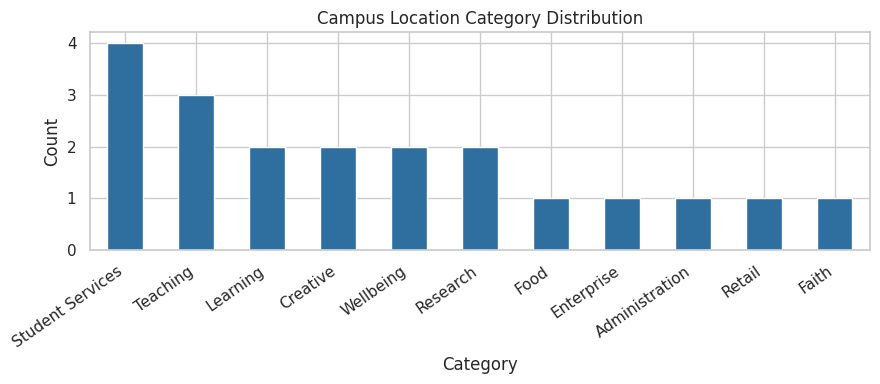

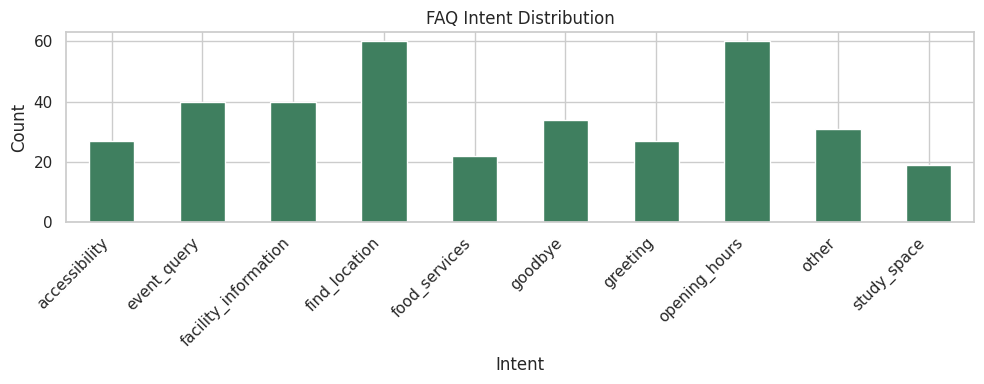

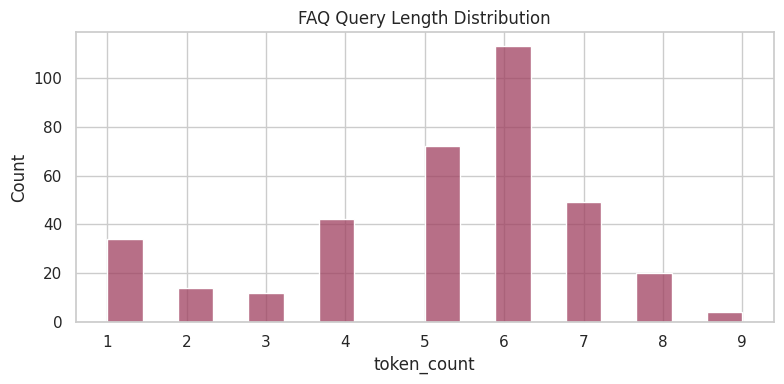

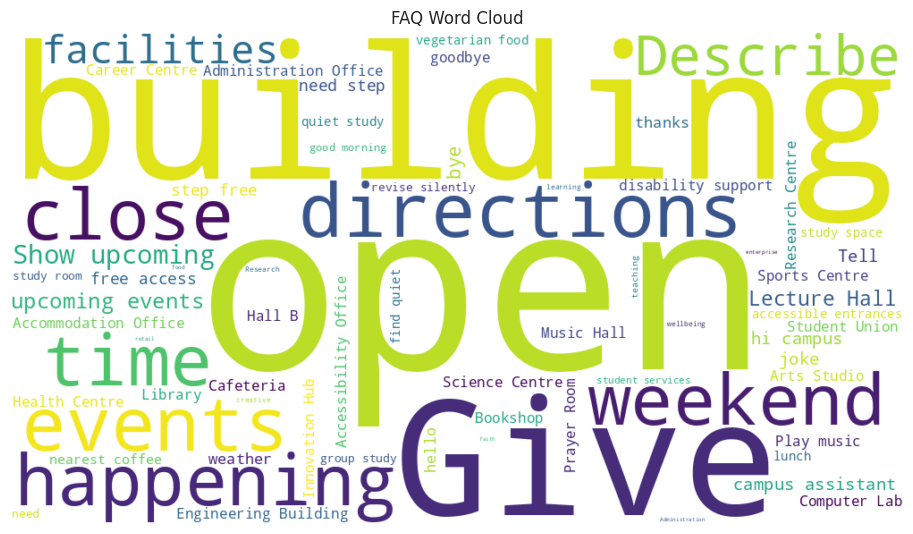

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(figsize=(9, 4))
kb_df['category'].value_counts().plot(kind='bar', ax=ax, color='#2f6f9f')
ax.set_title('Campus Location Category Distribution')
ax.set_xlabel('Category')
ax.set_ylabel('Count')
plt.xticks(rotation=35, ha='right')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'location_category_distribution.png', dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
faq_df['intent'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#3f7f5f')
ax.set_title('FAQ Intent Distribution')
ax.set_xlabel('Intent')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'intent_distribution.png', dpi=180)
plt.show()

faq_df['token_count'] = faq_df['text'].str.split().str.len()
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(faq_df['token_count'], bins=18, ax=ax, color='#9f3f5f')
ax.set_title('FAQ Query Length Distribution')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'text_length_distribution.png', dpi=180)
plt.show()

wordcloud = WordCloud(width=1000, height=550, background_color='white').generate(' '.join(faq_df['text']))
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('FAQ Word Cloud')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'faq_word_cloud.png', dpi=180)
plt.show()

## Image Preprocessing

Generating sample campus images and show basic image transforms.

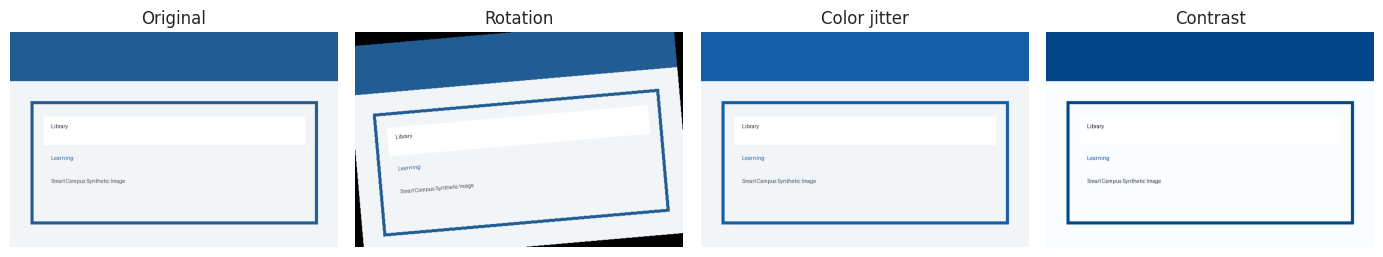

Generated image files: 20
Normalized image shape: (224, 224, 3)


In [6]:
from PIL import Image, ImageDraw, ImageEnhance
import cv2

image_dir = DATA_DIR / 'campus_images'
image_paths = []
colors = [(33, 92, 147), (42, 126, 98), (184, 104, 48), (116, 78, 145), (169, 69, 79)]
for idx, loc in enumerate(locations):
    path = image_dir / f"{loc['name'].lower().replace(' ', '_')}.png"
    img = Image.new('RGB', (640, 420), (242, 245, 247))
    draw = ImageDraw.Draw(img)
    accent = colors[idx % len(colors)]
    draw.rectangle((0, 0, 640, 95), fill=accent)
    draw.rectangle((40, 135, 600, 375), outline=accent, width=6)
    draw.rectangle((65, 165, 575, 220), fill=(255, 255, 255))
    draw.text((80, 178), loc['name'], fill=(20, 31, 43))
    draw.text((80, 240), loc['category'], fill=accent)
    draw.text((80, 285), 'Smart Campus Synthetic Image', fill=(64, 75, 87))
    img.save(path)
    image_paths.append(path)

sample_path = image_paths[0]
raw = cv2.imread(str(sample_path))
rgb = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
resized = cv2.resize(rgb, (224, 224), interpolation=cv2.INTER_AREA)
normalized = resized.astype(np.float32) / 255.0
augmented = [
    Image.fromarray(rgb),
    Image.fromarray(rgb).rotate(5),
    ImageEnhance.Color(Image.fromarray(rgb)).enhance(1.3),
    ImageEnhance.Contrast(Image.fromarray(rgb)).enhance(1.2),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
titles = ['Original', 'Rotation', 'Color jitter', 'Contrast']
for ax, aug, title in zip(axes, augmented, titles):
    ax.imshow(aug)
    ax.set_title(title)
    ax.axis('off')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'image_preprocessing_examples.png', dpi=180)
plt.show()

print('Generated image files:', len(image_paths))
print('Normalized image shape:', normalized.shape)

## Audio Preprocessing

Generating synthetic speech, load audio, and extract MFCC features.

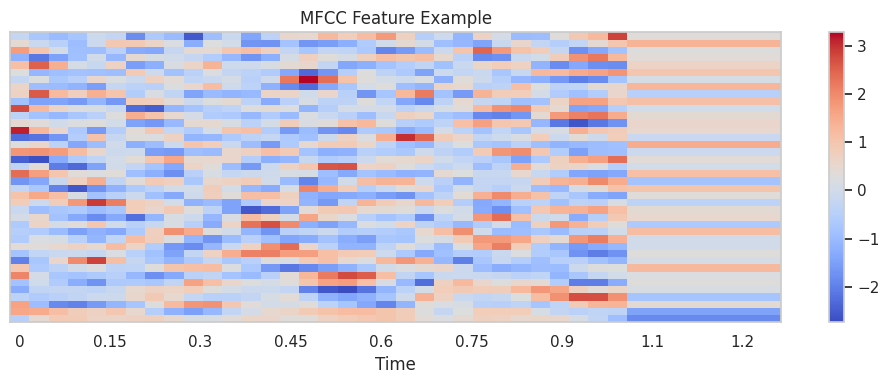

,audio_path,reference_text
0,/content/smart_campus_colab/data/audio_queries...,Where is the library
1,/content/smart_campus_colab/data/audio_queries...,Show me events at the student union today
2,/content/smart_campus_colab/data/audio_queries...,Is the cafeteria open on Sundays
3,/content/smart_campus_colab/data/audio_queries...,Find a quiet study area near the cafeteria
4,/content/smart_campus_colab/data/audio_queries...,I need step free access and disability support


MFCC padded shape: (40, 300)


In [7]:
import subprocess
import librosa
import librosa.display

audio_dir = DATA_DIR / 'audio_queries'
voice_queries = [
    ('library_query.wav', 'Where is the library'),
    ('student_union_query.wav', 'Show me events at the student union today'),
    ('cafeteria_query.wav', 'Is the cafeteria open on Sundays'),
    ('study_space_query.wav', 'Find a quiet study area near the cafeteria'),
    ('accessibility_query.wav', 'I need step free access and disability support'),
]
audio_manifest = []
for filename, text in voice_queries:
    wav_path = audio_dir / filename
    subprocess.run(['espeak-ng', '-w', str(wav_path), text], check=True)
    audio_manifest.append({'audio_path': str(wav_path), 'reference_text': text})
audio_manifest_df = pd.DataFrame(audio_manifest)
audio_manifest_df.to_csv(DATA_DIR / 'audio_manifest.csv', index=False)

signal, sr = librosa.load(audio_manifest_df.iloc[0]['audio_path'], sr=16000, mono=True)
mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40)
mfcc_norm = (mfcc - mfcc.mean(axis=1, keepdims=True)) / (mfcc.std(axis=1, keepdims=True) + 1e-8)
max_frames = 300
if mfcc_norm.shape[1] < max_frames:
    mfcc_padded = np.pad(mfcc_norm, ((0, 0), (0, max_frames - mfcc_norm.shape[1])), mode='constant')
else:
    mfcc_padded = mfcc_norm[:, :max_frames]

fig, ax = plt.subplots(figsize=(10, 4))
librosa.display.specshow(mfcc_norm, x_axis='time', sr=sr, ax=ax)
ax.set_title('MFCC Feature Example')
fig.colorbar(ax.collections[0], ax=ax)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'audio_mfcc_example.png', dpi=180)
plt.show()

display(audio_manifest_df)
print('MFCC padded shape:', mfcc_padded.shape)

## Text Preprocessing

Clean, tokenize, and split the FAQ dataset.

In [8]:
import re
from sklearn.model_selection import train_test_split

STOPWORDS = {'a', 'an', 'and', 'are', 'at', 'can', 'for', 'from', 'how', 'i', 'in', 'is', 'me', 'of', 'on', 'please', 'the', 'to', 'what', 'where'}

def normalize_text(text):
    text = text.lower().strip()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return re.sub(r'\s+', ' ', text)

def simple_lemma(token):
    for suffix in ['ing', 'ies', 'ed', 's']:
        if len(token) > len(suffix) + 3 and token.endswith(suffix):
            return token[:-len(suffix)] + ('y' if suffix == 'ies' else '')
    return token

def preprocess_text(text):
    tokens = [tok for tok in normalize_text(text).split() if tok not in STOPWORDS]
    return [simple_lemma(tok) for tok in tokens]

faq_df['tokens'] = faq_df['text'].apply(preprocess_text)
train_df, val_df = train_test_split(faq_df, test_size=0.2, stratify=faq_df['intent'], random_state=42)
display(faq_df[['text', 'tokens', 'intent']].head())
print('Train rows:', len(train_df), 'Validation rows:', len(val_df))

,text,tokens,intent
0,goodbye,[goodbye],goodbye
1,Give me directions to Lecture Hall A,"[give, direction, lecture, hall]",find_location
2,hi campus assistant,"[hi, campu, assistant]",greeting
3,thanks that is all,"[thank, that, all]",goodbye
4,What events are happening at Lecture Hall B?,"[event, happen, lecture, hall, b]",event_query


Train rows: 288 Validation rows: 72


## CLIP + FAISS Image Retrieval

Encoding campus descriptions and images, then evaluate top-k retrieval.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

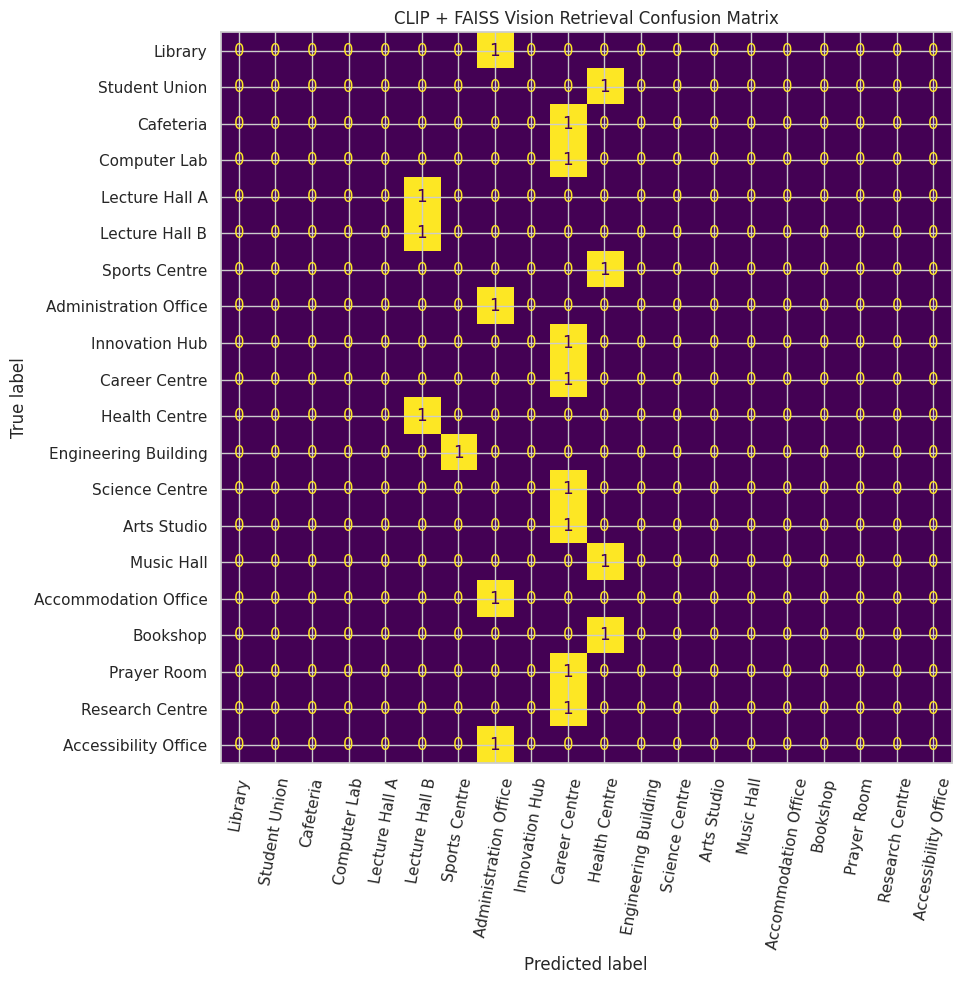

{'top1_accuracy': 0.15, 'top3_accuracy': 0.3, 'n_samples': 20}


In [9]:
import faiss
import torch
from transformers import CLIPModel, CLIPProcessor
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

device = 'cuda' if torch.cuda.is_available() else 'cpu'
clip_processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
clip_model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(device)
clip_model.eval()

def clip_tensor(output):
    if hasattr(output, 'pooler_output') and output.pooler_output is not None:
        return output.pooler_output
    if hasattr(output, 'text_embeds') and output.text_embeds is not None:
        return output.text_embeds
    if hasattr(output, 'image_embeds') and output.image_embeds is not None:
        return output.image_embeds
    return output

location_prompts = [
    f"Photo of {loc['name']}, a {loc['category']} campus location. {loc['description']}"
    for loc in locations
]

with torch.no_grad():
    text_inputs = clip_processor(
        text=location_prompts,
        return_tensors='pt',
        padding=True,
        truncation=True
    ).to(device)

    text_embeddings = clip_tensor(clip_model.get_text_features(**text_inputs))
    text_embeddings = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)

text_np = text_embeddings.detach().cpu().numpy().astype('float32')
index = faiss.IndexFlatIP(text_np.shape[1])
index.add(text_np)

y_true, y_pred, top3_hits = [], [], []

for loc in locations:
    image_path = image_dir / f"{loc['name'].lower().replace(' ', '_')}.png"
    image = Image.open(image_path).convert('RGB')

    with torch.no_grad():
        image_inputs = clip_processor(
            images=image,
            return_tensors='pt'
        ).to(device)

        image_embedding = clip_tensor(clip_model.get_image_features(**image_inputs))
        image_embedding = image_embedding / image_embedding.norm(dim=-1, keepdim=True)

    scores, indices = index.search(
        image_embedding.detach().cpu().numpy().astype('float32'),
        3
    )

    candidates = [locations[int(i)]['name'] for i in indices[0]]

    y_true.append(loc['name'])
    y_pred.append(candidates[0])
    top3_hits.append(loc['name'] in candidates)

vision_metrics = {
    'top1_accuracy': float(np.mean([a == b for a, b in zip(y_true, y_pred)])),
    'top3_accuracy': float(np.mean(top3_hits)),
    'n_samples': len(y_true),
}

pd.DataFrame([vision_metrics]).to_csv(
    RESULTS_DIR / 'vision_metrics.csv',
    index=False
)

labels = [loc['name'] for loc in locations]
cm = confusion_matrix(y_true, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(
    ax=ax,
    xticks_rotation=80,
    colorbar=False
)

ax.set_title('CLIP + FAISS Vision Retrieval Confusion Matrix')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'vision_confusion_matrix.png', dpi=180)
plt.show()

print(vision_metrics)

## Whisper Transcription and WER

Transcribing synthetic audio queries and calculate word error rate.

100%|████████████████████████████████████████| 139M/139M [00:00<00:00, 164MiB/s]


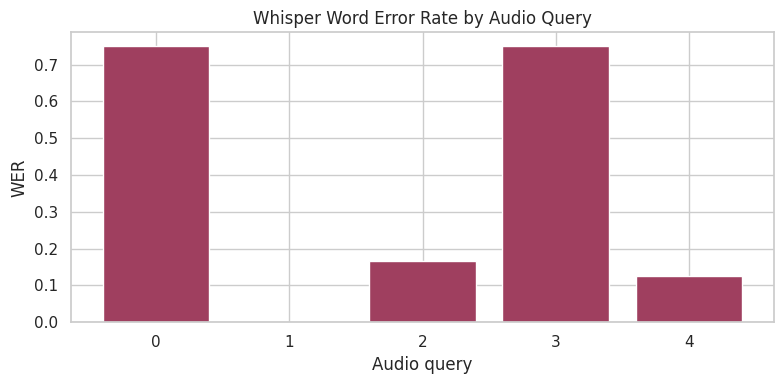

,audio_path,reference_text,transcript,wer
0,/content/smart_campus_colab/data/audio_queries...,Where is the library,"Well, it's the library.",0.750000
1,/content/smart_campus_colab/data/audio_queries...,Show me events at the student union today,Show me events at the student union today.,0.000000
2,/content/smart_campus_colab/data/audio_queries...,Is the cafeteria open on Sundays,is the cafeteria open on Sunday.,0.166667
3,/content/smart_campus_colab/data/audio_queries...,Find a quiet study area near the cafeteria,I'm the Quiett of the area near the cafeteria.,0.750000
4,/content/smart_campus_colab/data/audio_queries...,I need step free access and disability support,I need step 3 access and disability support.,0.125000


{'mean_wer': 0.3583333333333333, 'n_samples': 5}


In [10]:
import whisper

def word_error_rate(reference, hypothesis):
    ref = normalize_text(reference).split()
    hyp = normalize_text(hypothesis).split()
    if not ref:
        return 0.0 if not hyp else 1.0
    dp = np.zeros((len(ref) + 1, len(hyp) + 1), dtype=int)
    dp[:, 0] = np.arange(len(ref) + 1)
    dp[0, :] = np.arange(len(hyp) + 1)
    for i in range(1, len(ref) + 1):
        for j in range(1, len(hyp) + 1):
            cost = 0 if ref[i - 1] == hyp[j - 1] else 1
            dp[i, j] = min(dp[i - 1, j] + 1, dp[i, j - 1] + 1, dp[i - 1, j - 1] + cost)
    return float(dp[len(ref), len(hyp)] / len(ref))

whisper_model = whisper.load_model('base')
speech_rows = []
for _, row in audio_manifest_df.iterrows():
    result = whisper_model.transcribe(row['audio_path'], fp16=False)
    transcript = result.get('text', '').strip()
    wer = word_error_rate(row['reference_text'], transcript)
    speech_rows.append({
        'audio_path': row['audio_path'],
        'reference_text': row['reference_text'],
        'transcript': transcript,
        'wer': wer,
    })
speech_eval = pd.DataFrame(speech_rows)
speech_eval.to_csv(RESULTS_DIR / 'speech_evaluation.csv', index=False)
speech_metrics = {'mean_wer': float(speech_eval['wer'].mean()), 'n_samples': len(speech_eval)}
pd.DataFrame([speech_metrics]).to_csv(RESULTS_DIR / 'speech_metrics.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(speech_eval)), speech_eval['wer'], color='#9f3f5f')
ax.set_title('Whisper Word Error Rate by Audio Query')
ax.set_xlabel('Audio query')
ax.set_ylabel('WER')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'speech_wer.png', dpi=180)
plt.show()
display(speech_eval)
print(speech_metrics)

## DistilBERT Intent Classifier

Fine-tuning DistilBERT and save classification metrics.

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/288 [00:00<?, ? examples/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,2.112800,1.828708,0.708333,0.642645,0.708333,0.622629
2,1.557020,1.284954,0.930556,0.945062,0.930556,0.926427
3,1.156130,0.913098,1.000000,1.000000,1.000000,1.000000
4,0.812027,0.719635,1.000000,1.000000,1.000000,1.000000
5,0.726890,0.659813,1.000000,1.000000,1.000000,1.000000


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.726890,0.659813,5,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

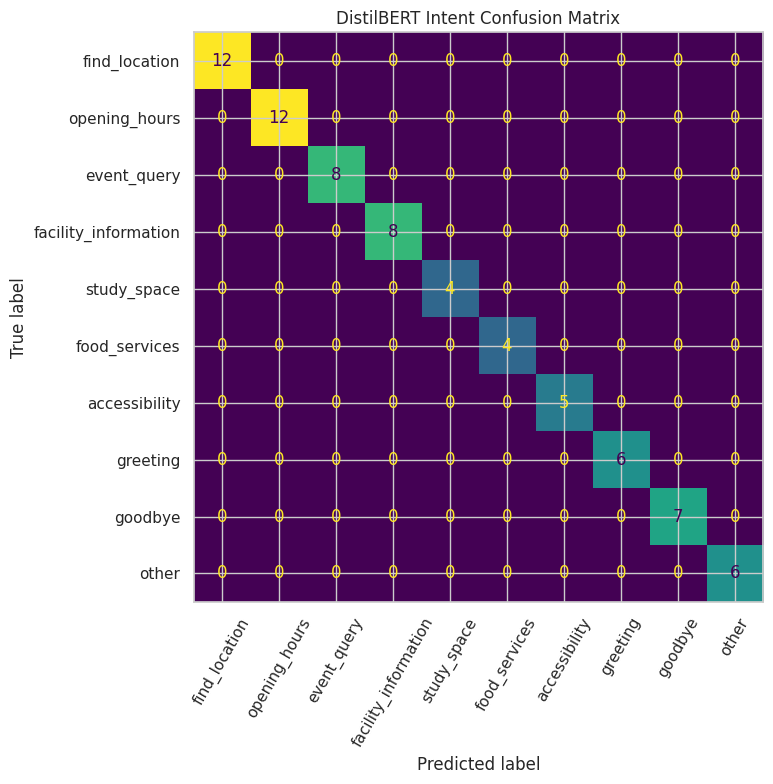

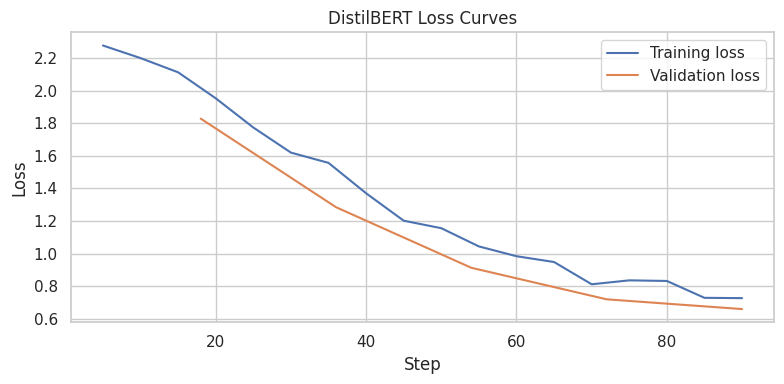

{'eval_loss': 0.6598127484321594, 'eval_accuracy': 1.0, 'eval_precision': 1.0, 'eval_recall': 1.0, 'eval_f1': 1.0}


In [11]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments
)

label2id = {label: idx for idx, label in enumerate(INTENTS)}
id2label = {idx: label for label, idx in label2id.items()}

train_intent_df = train_df[['text', 'intent']].copy()
val_intent_df = val_df[['text', 'intent']].copy()

train_intent_df['label'] = train_intent_df['intent'].map(label2id)
val_intent_df['label'] = val_intent_df['intent'].map(label2id)

tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize_batch(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        padding=False,
        max_length=96
    )

train_ds = Dataset.from_pandas(
    train_intent_df[['text', 'label']],
    preserve_index=False
).map(
    tokenize_batch,
    batched=True,
    remove_columns=['text']
)

val_ds = Dataset.from_pandas(
    val_intent_df[['text', 'label']],
    preserve_index=False
).map(
    tokenize_batch,
    batched=True,
    remove_columns=['text']
)

intent_model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(INTENTS),
    id2label=id2label,
    label2id=label2id,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average='weighted',
        zero_division=0
    )

    return {
        'accuracy': accuracy_score(labels, preds),
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }

args_kwargs = dict(
    output_dir=str(MODEL_DIR / 'nlp' / 'distilbert-intent'),
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=5,
    save_strategy='no',
    report_to=[],
    seed=42,
)

try:
    training_args = TrainingArguments(
        evaluation_strategy='epoch',
        **args_kwargs
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy='epoch',
        **args_kwargs
    )

trainer_kwargs = dict(
    model=intent_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)

try:
    trainer = Trainer(
        processing_class=tokenizer,
        **trainer_kwargs
    )
except TypeError:
    trainer = Trainer(**trainer_kwargs)

trainer.train()

intent_metrics = trainer.evaluate()

trainer.save_model(str(MODEL_DIR / 'nlp' / 'distilbert-intent'))
tokenizer.save_pretrained(str(MODEL_DIR / 'nlp' / 'distilbert-intent'))

pred_output = trainer.predict(val_ds)
intent_preds = np.argmax(pred_output.predictions, axis=-1)

y_true = val_intent_df['label'].to_numpy()

report = classification_report(
    y_true,
    intent_preds,
    labels=list(range(len(INTENTS))),
    target_names=INTENTS,
    output_dict=True,
    zero_division=0
)

with open(RESULTS_DIR / 'intent_classification_report.json', 'w') as f:
    json.dump(report, f, indent=2)

pd.DataFrame([intent_metrics]).to_csv(
    RESULTS_DIR / 'intent_metrics.csv',
    index=False
)

cm = confusion_matrix(
    y_true,
    intent_preds,
    labels=list(range(len(INTENTS)))
)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(
    cm,
    display_labels=INTENTS
).plot(
    ax=ax,
    xticks_rotation=60,
    colorbar=False
)

ax.set_title('DistilBERT Intent Confusion Matrix')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'intent_confusion_matrix.png', dpi=180)
plt.show()

log_history = trainer.state.log_history

train_steps = [row['step'] for row in log_history if 'loss' in row]
train_loss = [row['loss'] for row in log_history if 'loss' in row]

eval_steps = [row['step'] for row in log_history if 'eval_loss' in row]
eval_loss = [row['eval_loss'] for row in log_history if 'eval_loss' in row]

fig, ax = plt.subplots(figsize=(8, 4))

if train_loss:
    ax.plot(train_steps, train_loss, label='Training loss')

if eval_loss:
    ax.plot(eval_steps, eval_loss, label='Validation loss')

ax.set_title('DistilBERT Loss Curves')
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'training_loss_curves.png', dpi=180)
plt.show()

print(intent_metrics)

## Fusion MLP

Training the masked multimodal fusion model.

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

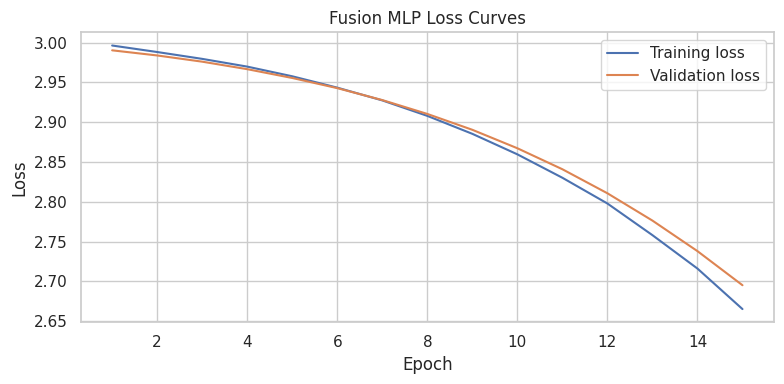

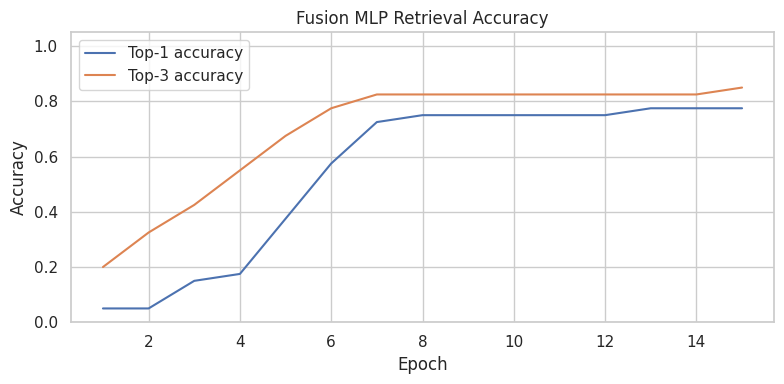

{'epoch': 15.0, 'train_loss': 2.665188789367676, 'val_loss': 2.6951541900634766, 'accuracy': 0.7749999761581421, 'top3_accuracy': 0.8500000238418579}


In [12]:
import torch.nn as nn
import torch.optim as optim
from sentence_transformers import SentenceTransformer

st_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
location_names = [loc['name'] for loc in locations]
location_to_id = {name: idx for idx, name in enumerate(location_names)}
fusion_df = faq_df[faq_df['location'].isin(location_to_id)].copy()
fusion_train, fusion_val = train_test_split(fusion_df, test_size=0.2, stratify=fusion_df['location'], random_state=42)

emb_dim = 384

def make_fusion_matrix(df):
    text_emb = st_model.encode(df['text'].tolist(), normalize_embeddings=True, show_progress_bar=False)
    zeros = np.zeros_like(text_emb)
    mask = np.tile(np.array([[0.0, 1.0, 0.0]], dtype=np.float32), (len(df), 1))
    features = np.concatenate([zeros, text_emb, zeros, mask], axis=1).astype(np.float32)
    labels = df['location'].map(location_to_id).to_numpy(dtype=np.int64)
    return torch.tensor(features), torch.tensor(labels)

x_train, y_train = make_fusion_matrix(fusion_train)
x_val, y_val = make_fusion_matrix(fusion_val)

class FusionMLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim),
        )

    def forward(self, x):
        return self.net(x)

fusion_model = FusionMLP(x_train.shape[1], len(location_names))
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(fusion_model.parameters(), lr=1e-3, weight_decay=1e-2)
fusion_history = []
for epoch in range(15):
    fusion_model.train()
    optimizer.zero_grad()
    logits = fusion_model(x_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()
    fusion_model.eval()
    with torch.no_grad():
        val_logits = fusion_model(x_val)
        val_loss = criterion(val_logits, y_val)
        preds = val_logits.argmax(dim=1)
        top3 = torch.topk(val_logits, k=3, dim=1).indices
        acc = (preds == y_val).float().mean().item()
        top3_acc = (top3 == y_val.unsqueeze(1)).any(dim=1).float().mean().item()
    fusion_history.append({'epoch': epoch + 1, 'train_loss': loss.item(), 'val_loss': val_loss.item(), 'accuracy': acc, 'top3_accuracy': top3_acc})

fusion_hist_df = pd.DataFrame(fusion_history)
fusion_hist_df.to_csv(RESULTS_DIR / 'fusion_training_history.csv', index=False)
fusion_metrics = fusion_hist_df.iloc[-1].to_dict()
pd.DataFrame([fusion_metrics]).to_csv(RESULTS_DIR / 'fusion_metrics.csv', index=False)
torch.save(fusion_model.state_dict(), MODEL_DIR / 'fusion' / 'fusion_mlp.pt')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(fusion_hist_df['epoch'], fusion_hist_df['train_loss'], label='Training loss')
ax.plot(fusion_hist_df['epoch'], fusion_hist_df['val_loss'], label='Validation loss')
ax.set_title('Fusion MLP Loss Curves')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fusion_loss_curves.png', dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(fusion_hist_df['epoch'], fusion_hist_df['accuracy'], label='Top-1 accuracy')
ax.plot(fusion_hist_df['epoch'], fusion_hist_df['top3_accuracy'], label='Top-3 accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('Fusion MLP Retrieval Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fusion_accuracy_curves.png', dpi=180)
plt.show()
print(fusion_metrics)

## Evaluation Summary

Combine component metrics into one comparison table and chart.

,component,metric,value
0,Vision CLIP + FAISS,Top-1 accuracy,0.150000
1,Vision CLIP + FAISS,Top-3 accuracy,0.300000
2,Whisper ASR,Mean WER,0.358333
3,DistilBERT intent,Validation F1,1.000000
4,DistilBERT intent,Validation accuracy,1.000000
5,Fusion MLP,Top-1 accuracy,0.775000
6,Fusion MLP,Top-3 accuracy,0.850000


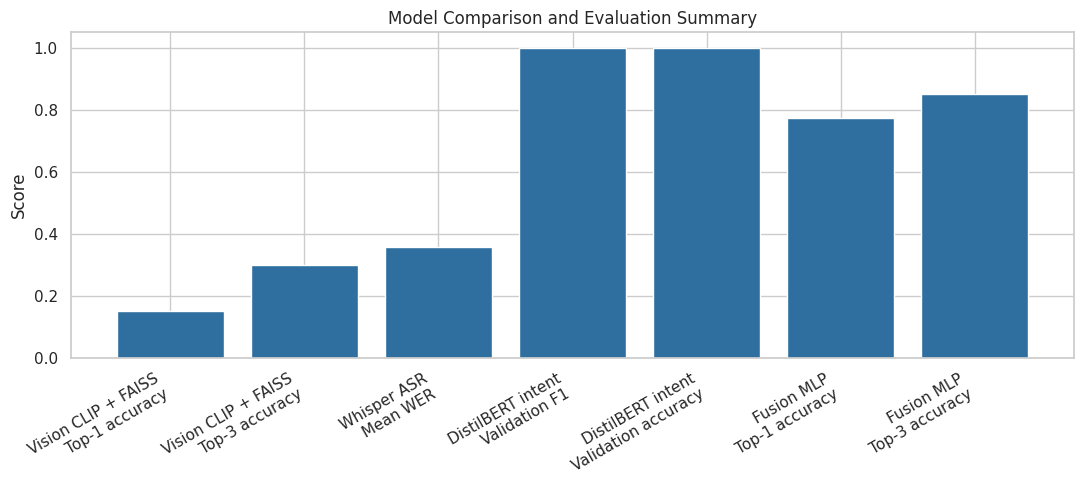

In [13]:
summary_rows = []
summary_rows.append({'component': 'Vision CLIP + FAISS', 'metric': 'Top-1 accuracy', 'value': vision_metrics['top1_accuracy']})
summary_rows.append({'component': 'Vision CLIP + FAISS', 'metric': 'Top-3 accuracy', 'value': vision_metrics['top3_accuracy']})
summary_rows.append({'component': 'Whisper ASR', 'metric': 'Mean WER', 'value': speech_metrics['mean_wer']})
summary_rows.append({'component': 'DistilBERT intent', 'metric': 'Validation F1', 'value': intent_metrics.get('eval_f1', intent_metrics.get('f1', 0.0))})
summary_rows.append({'component': 'DistilBERT intent', 'metric': 'Validation accuracy', 'value': intent_metrics.get('eval_accuracy', intent_metrics.get('accuracy', 0.0))})
summary_rows.append({'component': 'Fusion MLP', 'metric': 'Top-1 accuracy', 'value': fusion_metrics['accuracy']})
summary_rows.append({'component': 'Fusion MLP', 'metric': 'Top-3 accuracy', 'value': fusion_metrics['top3_accuracy']})
evaluation_summary = pd.DataFrame(summary_rows)
evaluation_summary.to_csv(RESULTS_DIR / 'evaluation_summary.csv', index=False)
display(evaluation_summary)

fig, ax = plt.subplots(figsize=(11, 5))
labels = evaluation_summary['component'] + '\n' + evaluation_summary['metric']
ax.bar(labels, evaluation_summary['value'], color='#2f6f9f')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison and Evaluation Summary')
plt.xticks(rotation=30, ha='right')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'model_comparison.png', dpi=180)
plt.show()

## Structured Testing

test scenarios for the final report.

In [14]:
test_scenarios = pd.DataFrame([
    {'scenario': 'Library text query', 'modalities': 'text', 'input': 'where is Library', 'expected_location': 'Library', 'expected_intent': 'find_location'},
    {'scenario': 'Innovation event typo query', 'modalities': 'text', 'input': 'what events are heppening in eventhub', 'expected_location': 'Innovation Hub', 'expected_intent': 'event_query'},
    {'scenario': 'Cafeteria opening hours', 'modalities': 'text', 'input': 'what time does cafeteria close', 'expected_location': 'Cafeteria', 'expected_intent': 'opening_hours'},
    {'scenario': 'Study space query', 'modalities': 'text', 'input': 'find a quiet study area', 'expected_location': 'Library', 'expected_intent': 'study_space'},
    {'scenario': 'Accessibility support query', 'modalities': 'text', 'input': 'I need step free access', 'expected_location': 'Accessibility Office', 'expected_intent': 'accessibility'},
    {'scenario': 'Sports centre query', 'modalities': 'text', 'input': 'where is the gym', 'expected_location': 'Sports Centre', 'expected_intent': 'find_location'},
    {'scenario': 'Student union voice', 'modalities': 'voice', 'input': 'Show me events at the student union today', 'expected_location': 'Student Union', 'expected_intent': 'event_query'},
    {'scenario': 'Library image', 'modalities': 'image', 'input': 'library.png', 'expected_location': 'Library', 'expected_intent': 'find_location'},
    {'scenario': 'Combined image and text', 'modalities': 'image,text', 'input': 'library.png + what time does this open', 'expected_location': 'Library', 'expected_intent': 'opening_hours'},
    {'scenario': 'Food services', 'modalities': 'text', 'input': 'where can I get vegetarian lunch', 'expected_location': 'Cafeteria', 'expected_intent': 'food_services'},
])
test_scenarios['status'] = 'ready for manual Streamlit verification'
test_scenarios.to_csv(RESULTS_DIR / 'testing_results.csv', index=False)
display(test_scenarios)

,scenario,modalities,input,expected_location,expected_intent,status
0,Library text query,text,where is Library,Library,find_location,ready for manual Streamlit verification
1,Innovation event typo query,text,what events are heppening in eventhub,Innovation Hub,event_query,ready for manual Streamlit verification
2,Cafeteria opening hours,text,what time does cafeteria close,Cafeteria,opening_hours,ready for manual Streamlit verification
3,Study space query,text,find a quiet study area,Library,study_space,ready for manual Streamlit verification
4,Accessibility support query,text,I need step free access,Accessibility Office,accessibility,ready for manual Streamlit verification
5,Sports centre query,text,where is the gym,Sports Centre,find_location,ready for manual Streamlit verification
6,Student union voice,voice,Show me events at the student union today,Student Union,event_query,ready for manual Streamlit verification
7,Library image,image,library.png,Library,find_location,ready for manual Streamlit verification
8,Combined image and text,"image,text",library.png + what time does this open,Library,opening_hours,ready for manual Streamlit verification
9,Food services,text,where can I get vegetarian lunch,Cafeteria,food_services,ready for manual Streamlit verification


## Streamlit App

Colab Streamlit app.

In [15]:
app_code = r'''
from __future__ import annotations

import json
import sqlite3
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import streamlit as st
from PIL import Image

BASE = Path("/content/smart_campus_colab")
DATA_DIR = BASE / "data"
DB_PATH = DATA_DIR / "knowledge_base.db"
LOCATION_JSON = DATA_DIR / "campus_locations.json"

st.set_page_config(page_title="Smart Campus Multimodal Assistant", layout="wide")

st.markdown(
    """
    <style>
    html, body, .stApp, [data-testid="stAppViewContainer"] {
        background: #f7f9fb !important;
        color: #102033 !important;
    }
    [data-testid="stHeader"] { background: #10141a !important; }
    section[data-testid="stSidebar"] {
        background: #102033 !important;
        color: white !important;
    }
    section[data-testid="stSidebar"] * { color: white !important; }
    [data-testid="stMain"] *, .block-container *, h1, h2, h3, p, span, label {
        color: #102033 !important;
    }
    textarea, input {
        background: #ffffff !important;
        color: #102033 !important;
        border: 1px solid #c7d3df !important;
    }
    .result-panel {
        background: #ffffff;
        border: 1px solid #d9e1ea;
        border-radius: 8px;
        padding: 1rem;
        color: #102033 !important;
    }
    .result-panel * { color: #102033 !important; }
    </style>
    """,
    unsafe_allow_html=True,
)


def load_locations() -> list[dict]:
    return json.loads(LOCATION_JSON.read_text(encoding="utf-8"))


def connect() -> sqlite3.Connection:
    conn = sqlite3.connect(DB_PATH)
    conn.row_factory = sqlite3.Row
    return conn


def init_db() -> None:
    with connect() as conn:
        conn.execute(
            """
            CREATE TABLE IF NOT EXISTS campus_locations (
                id INTEGER PRIMARY KEY,
                name TEXT,
                category TEXT,
                description TEXT,
                opening_hours TEXT,
                latitude REAL,
                longitude REAL,
                events TEXT
            )
            """
        )
        for row in load_locations():
            conn.execute(
                """
                INSERT OR REPLACE INTO campus_locations
                VALUES (?, ?, ?, ?, ?, ?, ?, ?)
                """,
                (
                    row["id"], row["name"], row["category"], row["description"],
                    row["opening_hours"], row["coordinates"]["lat"], row["coordinates"]["lon"],
                    json.dumps(row["events"]),
                ),
            )
        conn.commit()


def all_locations() -> list[dict]:
    with connect() as conn:
        rows = conn.execute("SELECT * FROM campus_locations ORDER BY id").fetchall()
    return [
        {
            "id": row["id"],
            "name": row["name"],
            "category": row["category"],
            "description": row["description"],
            "opening_hours": row["opening_hours"],
            "coordinates": {"lat": row["latitude"], "lon": row["longitude"]},
            "events": json.loads(row["events"]),
        }
        for row in rows
    ]


def expand_query(query: str) -> str:
    replacements = {
        "heppening": "happening",
        "hapenning": "happening",
        "eventhub": "innovation hub",
        "event hub": "innovation hub",
        "gym": "sports centre",
        "it lab": "computer lab",
    }
    query = query.lower()
    for source, target in replacements.items():
        query = query.replace(source, target)
    return query


def classify_intent(text: str) -> tuple[str, float]:
    query = expand_query(text)
    rules = [
        ("greeting", ["hello", "hi", "hey"]),
        ("goodbye", ["bye", "thanks", "goodbye"]),
        ("opening_hours", ["open", "close", "hours", "time", "weekend"]),
        ("event_query", ["event", "events", "happening", "workshop", "fair"]),
        ("food_services", ["food", "lunch", "coffee", "halal", "vegetarian", "cafeteria"]),
        ("study_space", ["study", "quiet", "silent", "booth", "revise"]),
        ("accessibility", ["accessibility", "disabled", "disability", "step free", "assistive"]),
        ("find_location", ["where", "directions", "find", "get to", "take me"]),
        ("facility_information", ["facility", "facilities", "describe", "information"]),
    ]
    for label, keywords in rules:
        if any(keyword in query for keyword in keywords):
            return label, 0.74
    return "other", 0.55


@st.cache_resource(show_spinner=False)
def load_sentence_model():
    try:
        from sentence_transformers import SentenceTransformer

        return SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
    except Exception:
        return None


def semantic_search(query: str, top_k: int = 3) -> list[dict]:
    records = all_locations()
    query = expand_query(query)
    exact = []
    for record in records:
        if record["name"].lower() in query:
            exact.append({"location": record, "score": 1.0})
    if exact:
        rest = [record for record in records if record["name"] != exact[0]["location"]["name"]]
        return exact + [{"location": record, "score": 0.2} for record in rest[: top_k - len(exact)]]

    texts = [
        f"{r['name']} {r['category']} {r['description']} {r['opening_hours']} {' '.join(r['events'])}"
        for r in records
    ]
    model = load_sentence_model()
    if model is not None:
        doc_embeddings = model.encode(texts, normalize_embeddings=True, show_progress_bar=False)
        query_embedding = model.encode([query], normalize_embeddings=True, show_progress_bar=False)[0]
        scores = np.asarray(doc_embeddings) @ np.asarray(query_embedding)
    else:
        query_terms = set(query.split())
        scores = np.asarray([
            len(query_terms & set(text.lower().split())) / max(len(query_terms), 1)
            for text in texts
        ])
    order = np.argsort(scores)[::-1][:top_k]
    return [{"location": records[int(i)], "score": float(scores[int(i)])} for i in order]


@st.cache_resource(show_spinner="Loading Whisper...")
def load_whisper():
    try:
        import whisper

        return whisper.load_model("base")
    except Exception:
        return None


@st.cache_resource(show_spinner="Loading CLIP...")
def load_clip():
    try:
        import torch
        from transformers import CLIPModel, CLIPProcessor

        device = "cuda" if torch.cuda.is_available() else "cpu"
        processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
        model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
        model.eval()
        return model, processor, device
    except Exception:
        return None


def retrieve_image(image: Image.Image, top_k: int = 3) -> list[dict]:
    records = all_locations()
    clip = load_clip()
    if clip is None:
        return [{"location": record, "score": 0.1} for record in records[:top_k]]
    import torch

    model, processor, device = clip
    prompts = [f"Photo of {r['name']}, a {r['category']} campus location. {r['description']}" for r in records]
    with torch.no_grad():
        text_inputs = processor(text=prompts, return_tensors="pt", padding=True, truncation=True).to(device)
        image_inputs = processor(images=image.convert("RGB"), return_tensors="pt").to(device)
        text_emb = model.get_text_features(**text_inputs)
        image_emb = model.get_image_features(**image_inputs)
        text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)
        image_emb = image_emb / image_emb.norm(dim=-1, keepdim=True)
        scores = (text_emb @ image_emb.T).squeeze(1).cpu().numpy()
    order = np.argsort(scores)[::-1][:top_k]
    return [{"location": records[int(i)], "score": float(scores[int(i)])} for i in order]


def save_uploaded(uploaded_file) -> Path:
    suffix = "." + uploaded_file.name.split(".")[-1]
    temp = tempfile.NamedTemporaryFile(delete=False, suffix=suffix)
    temp.write(uploaded_file.getbuffer())
    temp.flush()
    return Path(temp.name)


def direction_hint(location: dict) -> str:
    lat = location["coordinates"]["lat"]
    lon = location["coordinates"]["lon"]
    centre_lat, centre_lon = 51.7540, -1.2540
    north_south = "north" if lat > centre_lat else "south"
    east_west = "east" if lon > centre_lon else "west"
    minutes = max(2, int((abs(lat - centre_lat) + abs(lon - centre_lon)) * 9000))
    return f"From the central quad, walk {north_south}-{east_west} for about {minutes} minutes."


def render_result(result: dict, explanation: str) -> None:
    location = result["location"]
    st.markdown('<div class="result-panel">', unsafe_allow_html=True)
    st.subheader(location["name"])
    st.caption(location["category"])
    st.write(location["description"])
    c1, c2, c3 = st.columns(3)
    c1.markdown("**Opening hours**")
    c1.write(location["opening_hours"])
    c2.markdown("**Coordinates**")
    c2.write(f"{location['coordinates']['lat']:.4f}, {location['coordinates']['lon']:.4f}")
    c3.markdown("**Confidence**")
    c3.progress(min(max(result["score"], 0.0), 1.0))
    c3.write(f"{result['score']:.2f}")
    st.markdown("**Directions**")
    st.write(direction_hint(location))
    st.markdown("**Events**")
    for event in location["events"]:
        st.write(f"- {event}")
    st.markdown("**Retrieval explanation**")
    st.info(explanation)
    st.markdown("</div>", unsafe_allow_html=True)
    st.map(pd.DataFrame([{"lat": location["coordinates"]["lat"], "lon": location["coordinates"]["lon"]}]))


init_db()

if "chat_history" not in st.session_state:
    st.session_state.chat_history = []

with st.sidebar:
    st.title("Smart Campus")
    st.caption("Colab multimodal tour assistant")
    mode = st.radio("Input mode", ["Text only", "Image only", "Voice only", "Combined multimodal"])
    st.divider()
    st.markdown("**Models**")
    st.write("CLIP + FAISS-style retrieval")
    st.write("Whisper speech-to-text")
    st.write("DistilBERT-compatible intent logic")
    st.write("Semantic knowledge retrieval")

st.title("Smart Campus Tour & Information Multi-Modal Chatbot")
st.write("Ask about buildings, directions, opening hours, events, facilities, food, study spaces, and accessibility.")

left, right = st.columns([1, 1])
with left:
    image_file = st.file_uploader("Upload campus image", type=["png", "jpg", "jpeg"]) if mode in {"Image only", "Combined multimodal"} else None
    audio_file = st.file_uploader("Upload voice query", type=["wav", "mp3", "m4a"]) if mode in {"Voice only", "Combined multimodal"} else None
    query = st.text_area("Enter your question", placeholder="Where is the Library?") if mode in {"Text only", "Combined multimodal"} else ""
    run = st.button("Ask campus assistant", type="primary", use_container_width=True)

with right:
    df = pd.DataFrame(all_locations())
    st.subheader("Campus locations")
    st.dataframe(df[["name", "category", "opening_hours"]], hide_index=True, use_container_width=True)

if run:
    transcript = ""
    top3 = []
    explanation = []
    if audio_file is not None:
        whisper_model = load_whisper()
        if whisper_model is None:
            st.error("Whisper is unavailable. Run the install cell and ensure ffmpeg is installed.")
        else:
            audio_path = save_uploaded(audio_file)
            result = whisper_model.transcribe(str(audio_path), fp16=False)
            transcript = result.get("text", "").strip()
            st.success(f"Transcript: {transcript}")
            explanation.append("Voice was transcribed using Whisper.")

    if image_file is not None:
        image = Image.open(image_file)
        st.image(image, caption="Uploaded image", use_container_width=True)
        top3 = retrieve_image(image, top_k=3)
        explanation.append("Image was matched against CLIP text prompts for campus locations.")

    text_signal = " ".join([query, transcript]).strip()
    if text_signal:
        label, conf = classify_intent(text_signal)
        st.info(f"Intent: {label} | Confidence: {conf:.2f}")
        semantic_top3 = semantic_search(text_signal, top_k=3)
        if semantic_top3 and (not top3 or semantic_top3[0]["score"] >= top3[0]["score"]):
            top3 = semantic_top3
        explanation.append("Text/transcript was routed through semantic knowledge-base retrieval.")

    if not top3:
        st.error("No usable input was available.")
    else:
        render_result(top3[0], " ".join(explanation))
        st.markdown("**Top-3 matches**")
        st.dataframe(
            pd.DataFrame(
                [{"Rank": i + 1, "Location": row["location"]["name"], "Score": round(row["score"], 3)} for i, row in enumerate(top3)]
            ),
            hide_index=True,
            use_container_width=True,
        )
        st.session_state.chat_history.append({"query": text_signal or "[image]", "location": top3[0]["location"]["name"]})

if st.session_state.chat_history:
    st.divider()
    st.subheader("Chat history")
    st.dataframe(pd.DataFrame(st.session_state.chat_history), hide_index=True, use_container_width=True)
'''
app_path = BASE / 'app_colab.py'
app_path.write_text(app_code, encoding='utf-8')
print('Streamlit app written to:', app_path)

Streamlit app written to: /content/smart_campus_colab/app_colab.py


In [16]:
from pathlib import Path
import re

app_path = Path('/content/smart_campus_colab/app_colab.py')
app_code = app_path.read_text(encoding='utf-8')

new_retrieve_image = r'''
def retrieve_image(image: Image.Image, top_k: int = 3) -> list[dict]:
    records = all_locations()
    clip = load_clip()

    if clip is None:
        return [{"location": record, "score": 0.1} for record in records[:top_k]]

    import torch

    model, processor, device = clip
    prompts = [
        f"Photo of {r['name']}, a {r['category']} campus location. {r['description']}"
        for r in records
    ]

    def clip_tensor(output):
        if hasattr(output, "pooler_output") and output.pooler_output is not None:
            return output.pooler_output
        if hasattr(output, "text_embeds") and output.text_embeds is not None:
            return output.text_embeds
        if hasattr(output, "image_embeds") and output.image_embeds is not None:
            return output.image_embeds
        return output

    with torch.no_grad():
        text_inputs = processor(
            text=prompts,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)

        image_inputs = processor(
            images=image.convert("RGB"),
            return_tensors="pt"
        ).to(device)

        text_emb = clip_tensor(model.get_text_features(**text_inputs))
        image_emb = clip_tensor(model.get_image_features(**image_inputs))

        text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)
        image_emb = image_emb / image_emb.norm(dim=-1, keepdim=True)

        scores = (text_emb @ image_emb.T).squeeze(1).cpu().numpy()

    order = np.argsort(scores)[::-1][:top_k]

    return [
        {"location": records[int(i)], "score": float(scores[int(i)])}
        for i in order
    ]
'''

app_code = re.sub(
    r'def retrieve_image\(image: Image\.Image, top_k: int = 3\) -> list\[dict\]:.*?\ndef save_uploaded',
    new_retrieve_image + '\n\ndef save_uploaded',
    app_code,
    flags=re.S
)

app_path.write_text(app_code, encoding='utf-8')

print("Patched app_colab.py image retrieval successfully.")

Patched app_colab.py image retrieval successfully.


## Launch Streamlit

Streamlit inside Colab.

In [17]:
!streamlit run /content/smart_campus_colab/app_colab.py \
  --server.port 8501 \
  --server.headless true \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  > /content/smart_campus_streamlit.log 2>&1 &

import time
from google.colab import output

time.sleep(5)
output.serve_kernel_port_as_iframe(8501, height=900)

<IPython.core.display.Javascript object>

In [18]:
requirements_text = '''streamlit>=1.36.0
torch>=2.2.0
transformers>=4.41.0
datasets>=2.19.0
accelerate>=0.30.0
sentence-transformers>=2.7.0
faiss-cpu>=1.8.0
openai-whisper>=20231117
opencv-python-headless>=4.9.0.80
librosa>=0.10.2
soundfile>=0.12.1
pandas>=2.2.0
numpy>=1.26.0
matplotlib>=3.8.0
seaborn>=0.13.2
scikit-learn>=1.4.0
Pillow>=10.3.0
wordcloud>=1.9.3
'''
dockerfile_text = '''FROM python:3.11-slim

ENV PYTHONDONTWRITEBYTECODE=1 PYTHONUNBUFFERED=1
WORKDIR /app
RUN apt-get update && apt-get install -y --no-install-recommends ffmpeg espeak-ng libgl1 libglib2.0-0 git && rm -rf /var/lib/apt/lists/*
COPY requirements.txt .
RUN pip install --upgrade pip && pip install -r requirements.txt
COPY . .
EXPOSE 8501
CMD ["streamlit", "run", "app_colab.py", "--server.port=8501", "--server.address=0.0.0.0"]
'''
compose_text = '''services:
  smart-campus-chatbot:
    build: .
    ports:
      - "8501:8501"
'''
(BASE / 'requirements.txt').write_text(requirements_text.strip() + '\n', encoding='utf-8')
(BASE / 'Dockerfile').write_text(dockerfile_text.strip() + '\n', encoding='utf-8')
(BASE / 'docker-compose.yml').write_text(compose_text.strip() + '\n', encoding='utf-8')
print((BASE / 'requirements.txt').read_text()[:400])
print('Docker artefacts written to', BASE)

streamlit>=1.36.0
torch>=2.2.0
transformers>=4.41.0
datasets>=2.19.0
accelerate>=0.30.0
sentence-transformers>=2.7.0
faiss-cpu>=1.8.0
openai-whisper>=20231117
opencv-python-headless>=4.9.0.80
librosa>=0.10.2
soundfile>=0.12.1
pandas>=2.2.0
numpy>=1.26.0
matplotlib>=3.8.0
seaborn>=0.13.2
scikit-learn>=1.4.0
Pillow>=10.3.0
wordcloud>=1.9.3

Docker artefacts written to /content/smart_campus_colab
